# CIFAR-10 Image Classification -- ResNet50 Transfer Learning

## S1 - Imports & Configuration

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import torch
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import Subset, DataLoader
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models
from sklearn.metrics import classification_report, confusion_matrix
from dotenv import load_dotenv

# Load environment variables
load_dotenv()
PROJECT_PATH = os.getenv('PROJECT_ROOT')
DATA_PATH = os.getenv('DATA_PATH')

# Device configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
print(f"Project path: {PROJECT_PATH}")

Using device: cuda
Project path: Q:\scripts\projects\ComputerVision-Term9


## S2 - Data Loading & Sampling

In [2]:
# CIFAR-10 class labels
CLASS_NAMES = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

# Basic transform -- ToTensor scales 0-255 to 0-1 and converts to (C, H, W)
# Note: ImageNet normalization will be added in S4 Preprocessing for ResNet50
transform = transforms.Compose([
    transforms.ToTensor()
])

# Load full training set
full_train_dataset = torchvision.datasets.CIFAR10(
    root=DATA_PATH, train=True, download=True, transform=transform
)

# Limit to 10,000 samples as per project spec
train_subset = Subset(full_train_dataset, range(10000))

# Load test set (10,000 images by default -- no limiting needed)
test_dataset = torchvision.datasets.CIFAR10(
    root=DATA_PATH, train=False, download=True, transform=transform
)

print(f"Training subset size: {len(train_subset)}")
print(f"Test set size: {len(test_dataset)}")

100.0%


Extracting Q:\scripts\projects\ComputerVision-Term9\data\cifar-10-python.tar.gz to Q:\scripts\projects\ComputerVision-Term9\data


q:\scripts\projects\ComputerVision-Term9\.venv\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Files already downloaded and verified
Training subset size: 10000
Test set size: 10000


- ToTensor() is applied at load time as a PyTorch structural requirement,  
- ResNet50-specific normalization is intentionally deferred to S4.

## S3 - EDA

In [3]:
# Inspect a single sample
sample_image, sample_label = train_subset[0]

print(f"Image tensor shape: {sample_image.shape}")  # Expected: (3, 32, 32)
print(f"Image dtype: {sample_image.dtype}")
print(f"Pixel value range: {sample_image.min():.2f} - {sample_image.max():.2f}")
print(f"Sample label index: {sample_label}")
print(f"Sample label name: {CLASS_NAMES[sample_label]}")

Image tensor shape: torch.Size([3, 32, 32])
Image dtype: torch.float32
Pixel value range: 0.00 - 1.00
Sample label index: 6
Sample label name: frog


In [4]:
# Extract labels from the subset
labels = [full_train_dataset.targets[i] for i in range(10000)]

# Count per class
class_counts = {CLASS_NAMES[i]: labels.count(i) for i in range(10)}

print("Class distribution (10,000 sample subset):")
for cls, count in class_counts.items():
    print(f"  {cls:<12} {count}")

Class distribution (10,000 sample subset):
  airplane     1005
  automobile   974
  bird         1032
  cat          1016
  deer         999
  dog          937
  frog         1030
  horse        1001
  ship         1025
  truck        981


- subset is balanced  
- accuracy can be a reliable metric  
- no class weighting or resampling should be needed

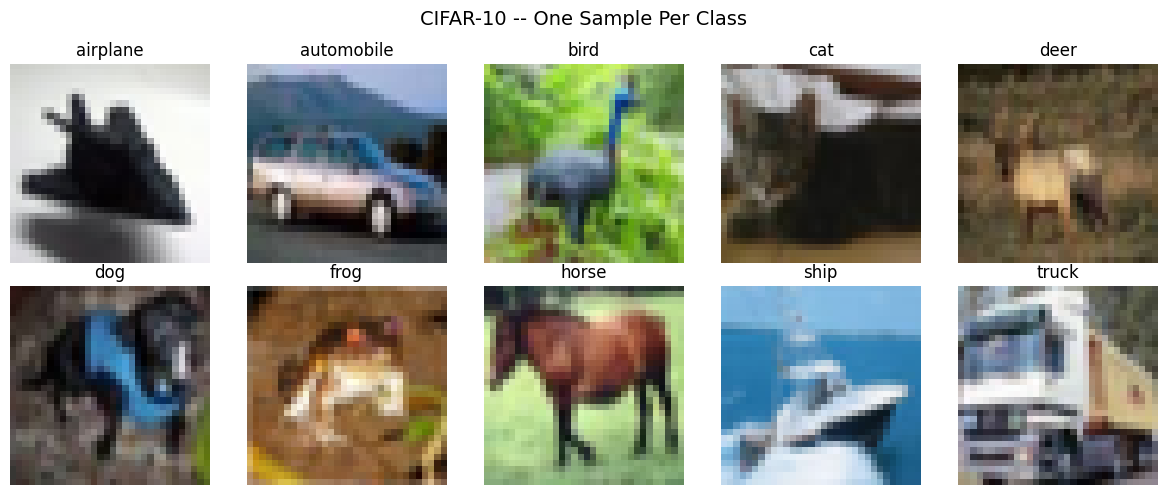

In [5]:
# Visualize one sample per class
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
axes = axes.flatten()

for class_idx in range(10):
    # Find first image matching this class
    match = next(i for i in range(10000) if full_train_dataset.targets[i] == class_idx)
    image, _ = train_subset[match]
    
    # Convert from (C, H, W) to (H, W, C) for matplotlib
    image = image.permute(1, 2, 0).numpy()
    
    axes[class_idx].imshow(image)
    axes[class_idx].set_title(CLASS_NAMES[class_idx])
    axes[class_idx].axis('off')

plt.suptitle('CIFAR-10 -- One Sample Per Class', fontsize=14)
plt.tight_layout()
plt.show()

## S4 - Preprocessing

In [ ]:
# S4: Updated transforms -- Resize + ImageNet Normalization for ResNet50
# Replaces S2 basic transform; ImageNet stats match pretrained weight expectations

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# Rebuild datasets with new transforms
full_train_dataset = torchvision.datasets.CIFAR10(
    root=DATA_PATH, train=True, download=True, transform=train_transform
)
train_subset = Subset(full_train_dataset, range(10000))
train_loader = DataLoader(train_subset, batch_size=32, shuffle=True)

test_dataset = torchvision.datasets.CIFAR10(
    root=DATA_PATH, train=False, download=True, transform=test_transform
)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# Verify output shape
images, labels = next(iter(train_loader))
print(f"Batch shape: {images.shape}")   # Expected: torch.Size([32, 3, 224, 224])
print(f"Dtype: {images.dtype}")         # Expected: torch.float32
print(f"Min/Max after norm: {images.min():.3f} / {images.max():.3f}")  # updated from [0,1]

Files already downloaded and verified
Files already downloaded and verified
Batch shape: torch.Size([32, 3, 224, 224])
Dtype: torch.float32
Min/Max after norm: -2.118 / 2.640


### S4: Preprocessing -- Resize + ImageNet Normalization
  
- Resize Decision  
    - ResNet50's convolutional filters are designed for 224x224 inputs.  
    - CIFAR-10's 32x32 format do not provide enough pixel context for the network's depth, quickly collapsing what litte data is available into insufficient spatial context to detect meaningful patterns.  
    - Upsampling to 224x224 preserves architectural integrity but adds interpolation artifacts (hopefully an acceptable tradeoff)
  
- ImageNet Normalization    
    - Mean: [0.485, 0.456, 0.406] | Std: [0.229, 0.224, 0.225]  
    - Applied to match distribution ResNet50's pretrained weights expect.  
    - Post-normalization pixel range is approximately [-2.1, 2.6]  
    - meaning the values have been recentered to the scale of the pretrained model  
  
- Verified Output  
    - Batch shape: torch.Size([32, 3, 224, 224])  
    - Dtype: torch.float32  
    - Normalized range: -2.118 / 2.640  

## S5 - Model Architecture

In [8]:
# S5: Model Architecture -- ResNet50 Transfer Learning

# Load pretrained ResNet50 with ImageNet weights
resnet50 = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)

# Freeze all base layers -- preserve pretrained ImageNet feature extraction
for param in resnet50.parameters():
    param.requires_grad = False

# Inspect the classifier we're replacing
print(f"Original ResNet50 head: {resnet50.fc}")
# Expected: Linear(in_features=2048, out_features=1000, bias=True)

# Build custom head -- note in_features=2048 matches ResNet50's final pool output
resnet50.fc = nn.Sequential(
    nn.Flatten(),
    nn.Linear(2048, 128),
    nn.ReLU(),
    nn.Linear(128, 64),
    nn.ReLU(),
    nn.Dropout(0.2),
    nn.Linear(64, 10)       # 10 CIFAR-10 classes; no Softmax -- CrossEntropyLoss handles it
)

# Move model to GPU if available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
resnet50 = resnet50.to(device)

print(f"\nDevice: {device}")
print(f"\nCustom head: {resnet50.fc}")
print(f"\nTrainable parameters: {sum(p.numel() for p in resnet50.parameters() if p.requires_grad):,}")

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to C:\Users\jason/.cache\torch\hub\checkpoints\resnet50-0676ba61.pth
100.0%


Original ResNet50 head: Linear(in_features=2048, out_features=1000, bias=True)

Device: cuda

Custom head: Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=2048, out_features=128, bias=True)
  (2): ReLU()
  (3): Linear(in_features=128, out_features=64, bias=True)
  (4): ReLU()
  (5): Dropout(p=0.2, inplace=False)
  (6): Linear(in_features=64, out_features=10, bias=True)
)

Trainable parameters: 271,178


### S5: Model Architecture -- ResNet50 Transfer Learning  
  
- Base Model  
    - ResNet50 loaded with ImageNet pretrained weights.  
    - All base layers frozen  
    - pretrained feature extraction preserved; only custom head trains initially.  

- Custom Head (replaces original 1000-class ImageNet classifier)  
    - Flatten -> Linear(2048, 128) -> ReLU -> Linear(128, 64) -> ReLU -> Dropout(0.2) -> Linear(64, 10)  

- Softmax Decision  
    - Explicit Softmax omitted  
    - PyTorch's CrossEntropyLoss applies log-softmax internally.  
    - Adding explicit Softmax would cause mathematical redundancy.  

- Verified Output  
    - Trainable parameters: 271,178 (custom head only)  
    - Total parameters: ~25M (base frozen)  
    - Device: CUDA (RTX 2060)  

## S6 - Training: Head Only

In [9]:
import torch.optim as optim
from torch.utils.data import random_split, DataLoader

# S6: Compilation Setup -- Optimizer, Loss, Validation Split, EarlyStopping

# 80/20 validation split from training subset
val_size = int(0.2 * len(train_subset))
train_size = len(train_subset) - val_size

train_split, val_split = random_split(train_subset, [train_size, val_size])

train_loader = DataLoader(train_split, batch_size=32, shuffle=True)
val_loader = DataLoader(val_split, batch_size=32, shuffle=False)

# Optimizer -- Adam on custom head parameters only (base frozen)
optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, resnet50.parameters()),
    lr=1e-3
)

# Loss function -- CrossEntropyLoss (includes log-softmax internally)
criterion = nn.CrossEntropyLoss()

# Training configuration
NUM_EPOCHS = 10
PATIENCE = 3

# EarlyStopping state
best_val_loss = float('inf')
patience_counter = 0
best_model_state = None

print(f"Train samples: {len(train_split)}")
print(f"Val samples: {len(val_split)}")
print(f"Optimizer: {optimizer}")
print(f"Loss: {criterion}")
print(f"Max epochs: {NUM_EPOCHS} | EarlyStopping patience: {PATIENCE}")

Train samples: 8000
Val samples: 2000
Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)
Loss: CrossEntropyLoss()
Max epochs: 10 | EarlyStopping patience: 3


### S6: Compilation Setup  

- Optimizer  
Adam, lr=1e-3. Applied only to trainable (custom head) parameters.  
AdamW with weight_decay noted as alternative for fine-tuning phase.  
(lr=1e-4 recommended when unfreezing base layers later.)

- Loss Function  
CrossEntropyLoss -- includes log-softmax internally.  
Explicit Softmax omitted from head (see S5 decision).  

- Validation Split  
80/20 split from 10,000 training samples.  
- Train: 8,000 | Validation: 2,000  

- EarlyStopping  
Patience = 3 -- training halts if validation loss fails to improve
for 3 consecutive epochs. Prevents wasted compute and overfitting.  

- Configuration  
- Max epochs: 10  
- Batch size: 32  

## S7 - Training loops

In [10]:
# S7: Training Loop -- Head Only (base frozen)

history = {
    'train_loss': [], 'train_acc': [],
    'val_loss': [], 'val_acc': []
}

for epoch in range(NUM_EPOCHS):
    # --- Training Phase ---
    resnet50.train()
    running_loss, correct, total = 0.0, 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = resnet50(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        correct += predicted.eq(labels).sum().item()
        total += labels.size(0)

    train_loss = running_loss / total
    train_acc = correct / total

    # --- Validation Phase ---
    resnet50.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = resnet50(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            val_correct += predicted.eq(labels).sum().item()
            val_total += labels.size(0)

    val_loss /= val_total
    val_acc = val_correct / val_total

    # --- Log ---
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    print(f"Epoch {epoch+1}/{NUM_EPOCHS} | "
          f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

    # --- EarlyStopping ---
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        best_model_state = resnet50.state_dict().copy()
        print(f"  >> New best val loss: {best_val_loss:.4f} -- model saved")
    else:
        patience_counter += 1
        print(f"  >> No improvement. Patience: {patience_counter}/{PATIENCE}")
        if patience_counter >= PATIENCE:
            print("Early stopping triggered.")
            break

# Restore best weights
resnet50.load_state_dict(best_model_state)
print("Best model weights restored.")

Epoch 1/10 | Train Loss: 1.3587 | Train Acc: 0.5209 | Val Loss: 0.7632 | Val Acc: 0.7550
  >> New best val loss: 0.7632 -- model saved
Epoch 2/10 | Train Loss: 0.8610 | Train Acc: 0.6995 | Val Loss: 0.6737 | Val Acc: 0.7645
  >> New best val loss: 0.6737 -- model saved
Epoch 3/10 | Train Loss: 0.7684 | Train Acc: 0.7412 | Val Loss: 0.6692 | Val Acc: 0.7745
  >> New best val loss: 0.6692 -- model saved
Epoch 4/10 | Train Loss: 0.7049 | Train Acc: 0.7602 | Val Loss: 0.6232 | Val Acc: 0.7800
  >> New best val loss: 0.6232 -- model saved
Epoch 5/10 | Train Loss: 0.6598 | Train Acc: 0.7704 | Val Loss: 0.5824 | Val Acc: 0.8085
  >> New best val loss: 0.5824 -- model saved
Epoch 6/10 | Train Loss: 0.6522 | Train Acc: 0.7790 | Val Loss: 0.5953 | Val Acc: 0.7935
  >> No improvement. Patience: 1/3
Epoch 7/10 | Train Loss: 0.6125 | Train Acc: 0.7905 | Val Loss: 0.5936 | Val Acc: 0.7955
  >> No improvement. Patience: 2/3
Epoch 8/10 | Train Loss: 0.6036 | Train Acc: 0.7971 | Val Loss: 0.6090 | Val 

### S7 -- Training History Plot

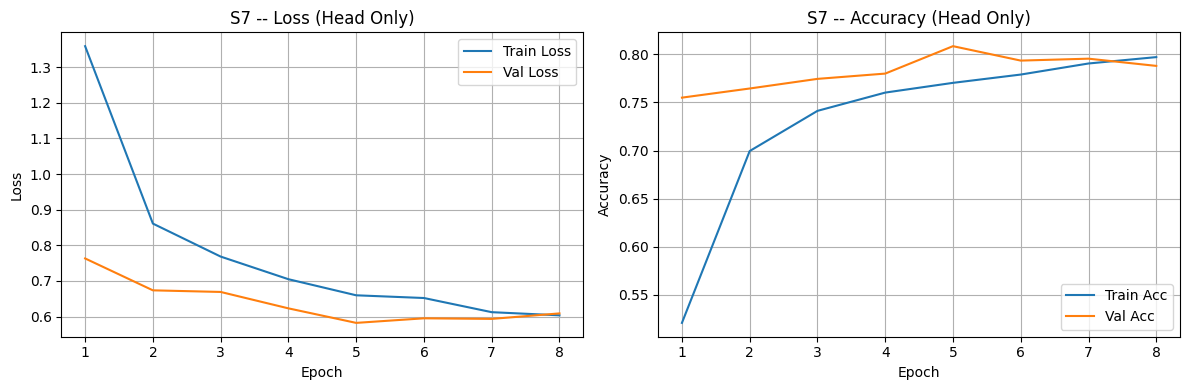

Plot saved: s7_training_history.png


In [11]:
# S7: Training History Plot

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

epochs_ran = range(1, len(history['train_loss']) + 1)

# Loss
ax1.plot(epochs_ran, history['train_loss'], label='Train Loss')
ax1.plot(epochs_ran, history['val_loss'], label='Val Loss')
ax1.set_title('S7 -- Loss (Head Only)')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True)

# Accuracy
ax2.plot(epochs_ran, history['train_acc'], label='Train Acc')
ax2.plot(epochs_ran, history['val_acc'], label='Val Acc')
ax2.set_title('S7 -- Accuracy (Head Only)')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.savefig('s7_training_history.png', dpi=150)
plt.show()
print("Plot saved: s7_training_history.png")

### S7: Training Results -- Head Only
- Best val loss: 0.5824 (Epoch 5) | Best val acc: 80.85%
- Early stopping triggered at Epoch 8 (patience=3)
- Train/val crossover ~Epoch 7-8 confirms correct stopping point
- Base remains frozen; head trained to near-ceiling for frozen features

## S8 - Fine-Tuning: Full Model

In [12]:
# S8 Prep: Save S7 best weights as starting point for both fine-tuning runs
import os

CHECKPOINT_DIR = os.path.join(PROJECT_PATH, 'checkpoints')
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

S7_CHECKPOINT = os.path.join(CHECKPOINT_DIR, 's7_best_weights.pth')
torch.save(best_model_state, S7_CHECKPOINT)

print(f"S7 weights saved to: {S7_CHECKPOINT}")

S7 weights saved to: Q:\scripts\projects\ComputerVision-Term9\checkpoints\s7_best_weights.pth


### S8a Full Unfreeze

In [14]:
# S8a: Full Unfreeze -- AdamW lr=1e-4
# Load S7 weights as starting point
resnet50.load_state_dict(torch.load(S7_CHECKPOINT, weights_only=True))

# Unfreeze all parameters
for param in resnet50.parameters():
    param.requires_grad = True

# Verify trainable parameter count
total_params = sum(p.numel() for p in resnet50.parameters() if p.requires_grad)
print(f"Trainable parameters (S8a): {total_params:,}")

# AdamW optimizer -- all parameters, lr=1e-4
optimizer_s8a = optim.AdamW(resnet50.parameters(), lr=1e-4)

# Reset EarlyStopping state
best_val_loss = float('inf')
patience_counter = 0
best_model_state_s8a = None

print("S8a ready -- full unfreeze, AdamW lr=1e-4")

Trainable parameters (S8a): 23,779,210
S8a ready -- full unfreeze, AdamW lr=1e-4


In [15]:
# S8a: Training Loop -- Full Unfreeze
history_s8a = {
    'train_loss': [], 'train_acc': [],
    'val_loss': [], 'val_acc': []
}

for epoch in range(NUM_EPOCHS):
    resnet50.train()
    running_loss, correct, total = 0.0, 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer_s8a.zero_grad()
        outputs = resnet50(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer_s8a.step()

        running_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        correct += predicted.eq(labels).sum().item()
        total += labels.size(0)

    train_loss = running_loss / total
    train_acc = correct / total

    resnet50.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = resnet50(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            val_correct += predicted.eq(labels).sum().item()
            val_total += labels.size(0)

    val_loss /= val_total
    val_acc = val_correct / val_total

    history_s8a['train_loss'].append(train_loss)
    history_s8a['train_acc'].append(train_acc)
    history_s8a['val_loss'].append(val_loss)
    history_s8a['val_acc'].append(val_acc)

    print(f"Epoch {epoch+1}/{NUM_EPOCHS} | "
          f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        best_model_state_s8a = resnet50.state_dict().copy()
        print(f"  >> New best val loss: {best_val_loss:.4f} -- S8a model saved")
    else:
        patience_counter += 1
        print(f"  >> No improvement. Patience: {patience_counter}/{PATIENCE}")
        if patience_counter >= PATIENCE:
            print("Early stopping triggered.")
            break

resnet50.load_state_dict(best_model_state_s8a)
S8A_CHECKPOINT = os.path.join(CHECKPOINT_DIR, 's8a_best_weights.pth')
torch.save(best_model_state_s8a, S8A_CHECKPOINT)
print(f"S8a best weights saved to: {S8A_CHECKPOINT}")

Epoch 1/10 | Train Loss: 0.4781 | Train Acc: 0.8434 | Val Loss: 0.3009 | Val Acc: 0.9030
  >> New best val loss: 0.3009 -- S8a model saved
Epoch 2/10 | Train Loss: 0.1974 | Train Acc: 0.9374 | Val Loss: 0.3424 | Val Acc: 0.8935
  >> No improvement. Patience: 1/3
Epoch 3/10 | Train Loss: 0.1549 | Train Acc: 0.9511 | Val Loss: 0.3956 | Val Acc: 0.8765
  >> No improvement. Patience: 2/3
Epoch 4/10 | Train Loss: 0.1119 | Train Acc: 0.9654 | Val Loss: 0.4078 | Val Acc: 0.8910
  >> No improvement. Patience: 3/3
Early stopping triggered.
S8a best weights saved to: Q:\scripts\projects\ComputerVision-Term9\checkpoints\s8a_best_weights.pth


#### S8a: Full Unfreeze Results
- Best val acc: 90.30% (Epoch 1) | Best val loss: 0.3009
- Early stopping triggered at Epoch 4
- Rapid overfitting: train acc 96.5% vs val acc 89.1% by epoch 4
- Constraint: 10k training samples insufficient for 23.7M free parameters

### S8b Full Unfreeze

In [16]:
# S8b: Layer4 Selective Unfreeze -- AdamW lr=1e-4
# Reload S7 weights as clean starting point
resnet50.load_state_dict(torch.load(S7_CHECKPOINT, weights_only=True))

# Freeze everything first
for param in resnet50.parameters():
    param.requires_grad = False

# Unfreeze layer4 and custom head only
for param in resnet50.layer4.parameters():
    param.requires_grad = True
for param in resnet50.fc.parameters():
    param.requires_grad = True

# Verify
trainable = sum(p.numel() for p in resnet50.parameters() if p.requires_grad)
print(f"Trainable parameters (S8b): {trainable:,}")
# Expected: ~8.4M (layer4) + 271K (head)

# AdamW optimizer -- trainable parameters only
optimizer_s8b = optim.AdamW(
    filter(lambda p: p.requires_grad, resnet50.parameters()), lr=1e-4
)

# Reset EarlyStopping state
best_val_loss = float('inf')
patience_counter = 0
best_model_state_s8b = None

print("S8b ready -- layer4 + head, AdamW lr=1e-4")

Trainable parameters (S8b): 15,235,914
S8b ready -- layer4 + head, AdamW lr=1e-4


In [17]:
# S8b: Training Loop -- Layer4 Selective Unfreeze
history_s8b = {
    'train_loss': [], 'train_acc': [],
    'val_loss': [], 'val_acc': []
}

for epoch in range(NUM_EPOCHS):
    resnet50.train()
    running_loss, correct, total = 0.0, 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer_s8b.zero_grad()
        outputs = resnet50(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer_s8b.step()

        running_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        correct += predicted.eq(labels).sum().item()
        total += labels.size(0)

    train_loss = running_loss / total
    train_acc = correct / total

    resnet50.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = resnet50(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            val_correct += predicted.eq(labels).sum().item()
            val_total += labels.size(0)

    val_loss /= val_total
    val_acc = val_correct / val_total

    history_s8b['train_loss'].append(train_loss)
    history_s8b['train_acc'].append(train_acc)
    history_s8b['val_loss'].append(val_loss)
    history_s8b['val_acc'].append(val_acc)

    print(f"Epoch {epoch+1}/{NUM_EPOCHS} | "
          f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        best_model_state_s8b = resnet50.state_dict().copy()
        print(f"  >> New best val loss: {best_val_loss:.4f} -- S8b model saved")
    else:
        patience_counter += 1
        print(f"  >> No improvement. Patience: {patience_counter}/{PATIENCE}")
        if patience_counter >= PATIENCE:
            print("Early stopping triggered.")
            break

resnet50.load_state_dict(best_model_state_s8b)
S8B_CHECKPOINT = os.path.join(CHECKPOINT_DIR, 's8b_best_weights.pth')
torch.save(best_model_state_s8b, S8B_CHECKPOINT)
print(f"S8b best weights saved to: {S8B_CHECKPOINT}")

Epoch 1/10 | Train Loss: 0.5532 | Train Acc: 0.8201 | Val Loss: 0.4248 | Val Acc: 0.8585
  >> New best val loss: 0.4248 -- S8b model saved
Epoch 2/10 | Train Loss: 0.2093 | Train Acc: 0.9311 | Val Loss: 0.4001 | Val Acc: 0.8640
  >> New best val loss: 0.4001 -- S8b model saved
Epoch 3/10 | Train Loss: 0.1278 | Train Acc: 0.9610 | Val Loss: 0.4456 | Val Acc: 0.8685
  >> No improvement. Patience: 1/3
Epoch 4/10 | Train Loss: 0.0869 | Train Acc: 0.9725 | Val Loss: 0.4283 | Val Acc: 0.8765
  >> No improvement. Patience: 2/3
Epoch 5/10 | Train Loss: 0.0730 | Train Acc: 0.9760 | Val Loss: 0.5255 | Val Acc: 0.8630
  >> No improvement. Patience: 3/3
Early stopping triggered.
S8b best weights saved to: Q:\scripts\projects\ComputerVision-Term9\checkpoints\s8b_best_weights.pth


#### S8b: Layer4 Selective Unfreeze Results
- Best val acc: 86.40% (Epoch 2) | Best val loss: 0.4001
- Early stopping triggered at Epoch 5
- Overfitting persisted despite selective unfreezing -- 10k dataset size identified as binding constraint
- S8a (full unfreeze) outperformed S8b -- suggests layer4 alone insufficient for CIFAR-10 adaptation at this scale
- Future experiment: repeat with 50k training samples (see S8c notes)

### Comparison Plots

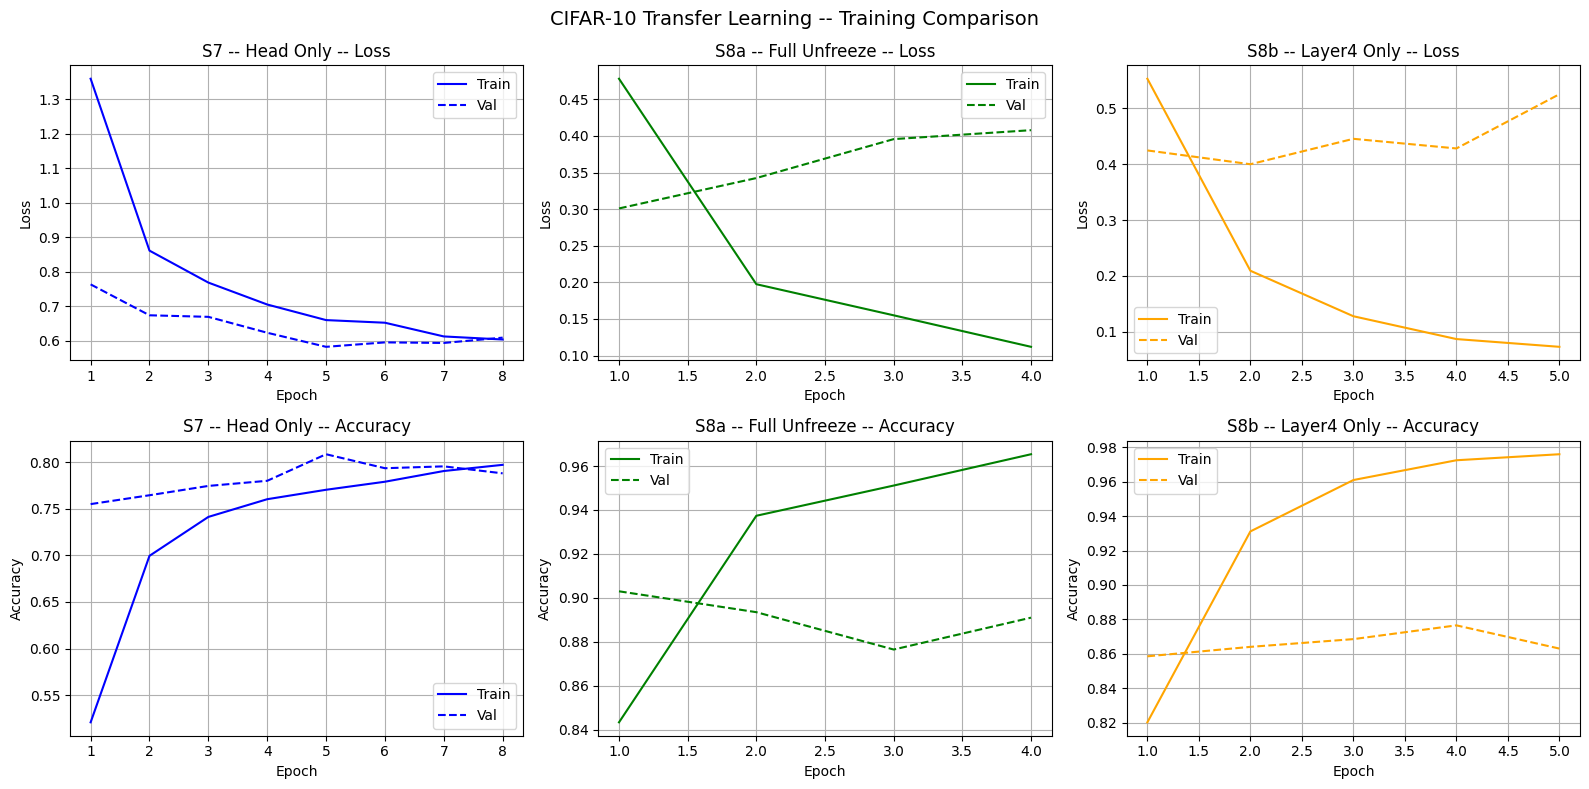

Plot saved: s8_comparison.png


In [18]:
# S8: Three-way comparison plot -- S7, S8a, S8b

fig, axes = plt.subplots(2, 3, figsize=(16, 8))

stages = [
    ('S7 -- Head Only',      history,      'blue'),
    ('S8a -- Full Unfreeze', history_s8a,  'green'),
    ('S8b -- Layer4 Only',   history_s8b,  'orange'),
]

for col, (title, hist, color) in enumerate(stages):
    epochs_ran = range(1, len(hist['train_loss']) + 1)

    # Loss
    axes[0, col].plot(epochs_ran, hist['train_loss'], label='Train', color=color)
    axes[0, col].plot(epochs_ran, hist['val_loss'], label='Val', color=color, linestyle='--')
    axes[0, col].set_title(f'{title} -- Loss')
    axes[0, col].set_xlabel('Epoch')
    axes[0, col].set_ylabel('Loss')
    axes[0, col].legend()
    axes[0, col].grid(True)

    # Accuracy
    axes[1, col].plot(epochs_ran, hist['train_acc'], label='Train', color=color)
    axes[1, col].plot(epochs_ran, hist['val_acc'], label='Val', color=color, linestyle='--')
    axes[1, col].set_title(f'{title} -- Accuracy')
    axes[1, col].set_xlabel('Epoch')
    axes[1, col].set_ylabel('Accuracy')
    axes[1, col].legend()
    axes[1, col].grid(True)

plt.suptitle('CIFAR-10 Transfer Learning -- Training Comparison', fontsize=14)
plt.tight_layout()
plt.savefig('s8_comparison.png', dpi=150)
plt.show()
print("Plot saved: s8_comparison.png")

### Future Experiments (flagged during S8)
- S8c: layer3+4 unfreeze, AdamW lr=1e-4 -- low-res images may benefit from layer3 adaptation
- S8d: layer4 only, AdamW lr=1e-3 -- test aggressive fine-tuning from S7 weights
- Phase 4: repeat pipeline with full 50k training set, 60/40 split

## S9 - Evaluation

### Test set evaluation

In [19]:
# S9 Cell 1: Test Set Evaluation -- All Three Models

def evaluate_model(model, loader, criterion, device, label):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            correct += predicted.eq(labels).sum().item()
            total += labels.size(0)

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / total
    accuracy = correct / total
    print(f"{label} | Test Loss: {avg_loss:.4f} | Test Acc: {accuracy:.4f} ({accuracy*100:.2f}%)")
    return avg_loss, accuracy, all_preds, all_labels

# Evaluate all three -- reload checkpoints explicitly
checkpoints = [
    ('S7  -- Head Only',      S7_CHECKPOINT),
    ('S8a -- Full Unfreeze',  S8A_CHECKPOINT),
    ('S8b -- Layer4 Only',    S8B_CHECKPOINT),
]

results = {}
for label, checkpoint in checkpoints:
    resnet50.load_state_dict(torch.load(checkpoint, weights_only=True))
    loss, acc, preds, labels_true = evaluate_model(
        resnet50, test_loader, criterion, device, label
    )
    results[label] = {
        'loss': loss, 'acc': acc,
        'preds': preds, 'labels': labels_true
    }

S7  -- Head Only | Test Loss: 0.6376 | Test Acc: 0.7802 (78.02%)
S8a -- Full Unfreeze | Test Loss: 0.3918 | Test Acc: 0.8949 (89.49%)
S8b -- Layer4 Only | Test Loss: 0.5771 | Test Acc: 0.8562 (85.62%)


### Misclassification Grid

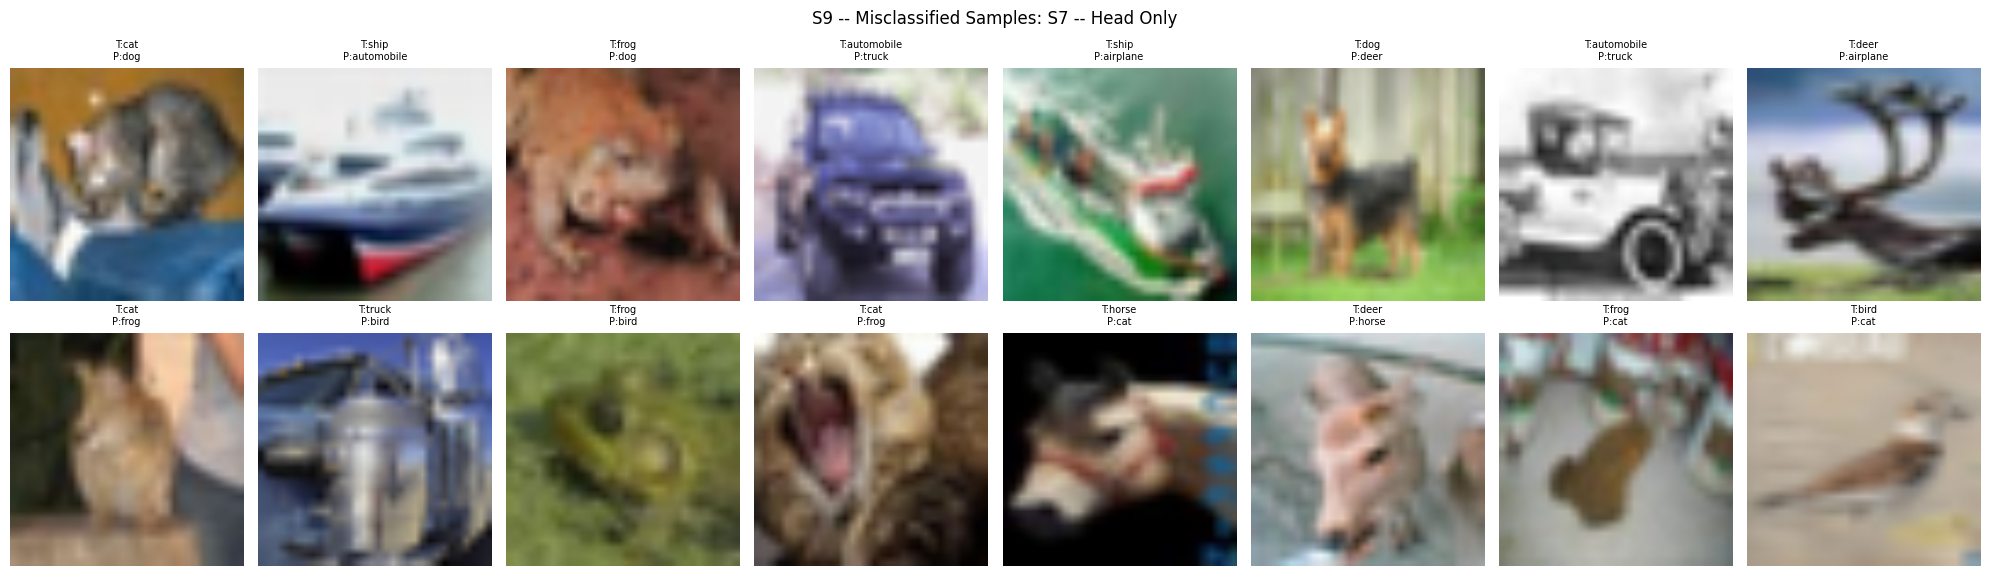

Saved: s9_misclass_s7.png


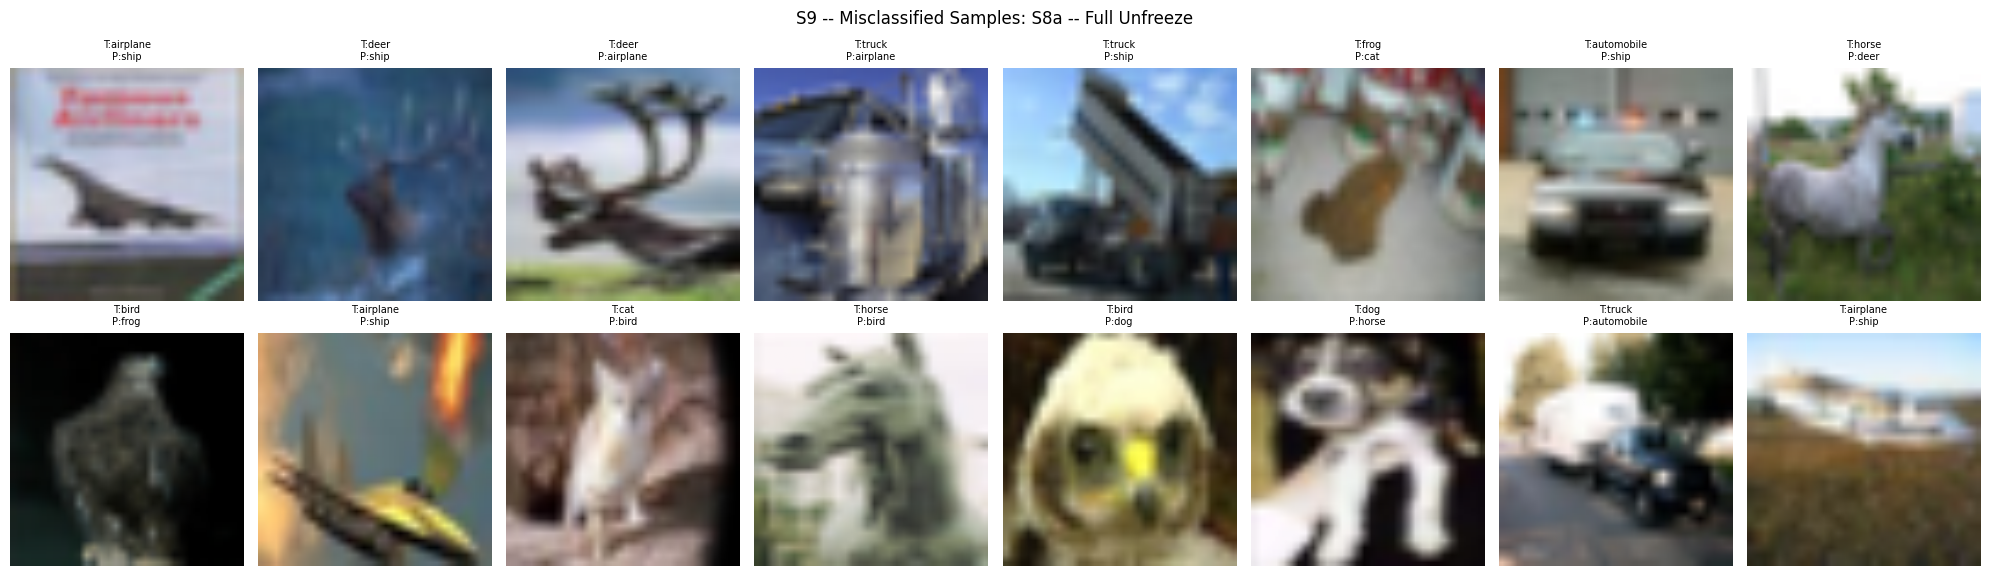

Saved: s9_misclass_s8a.png


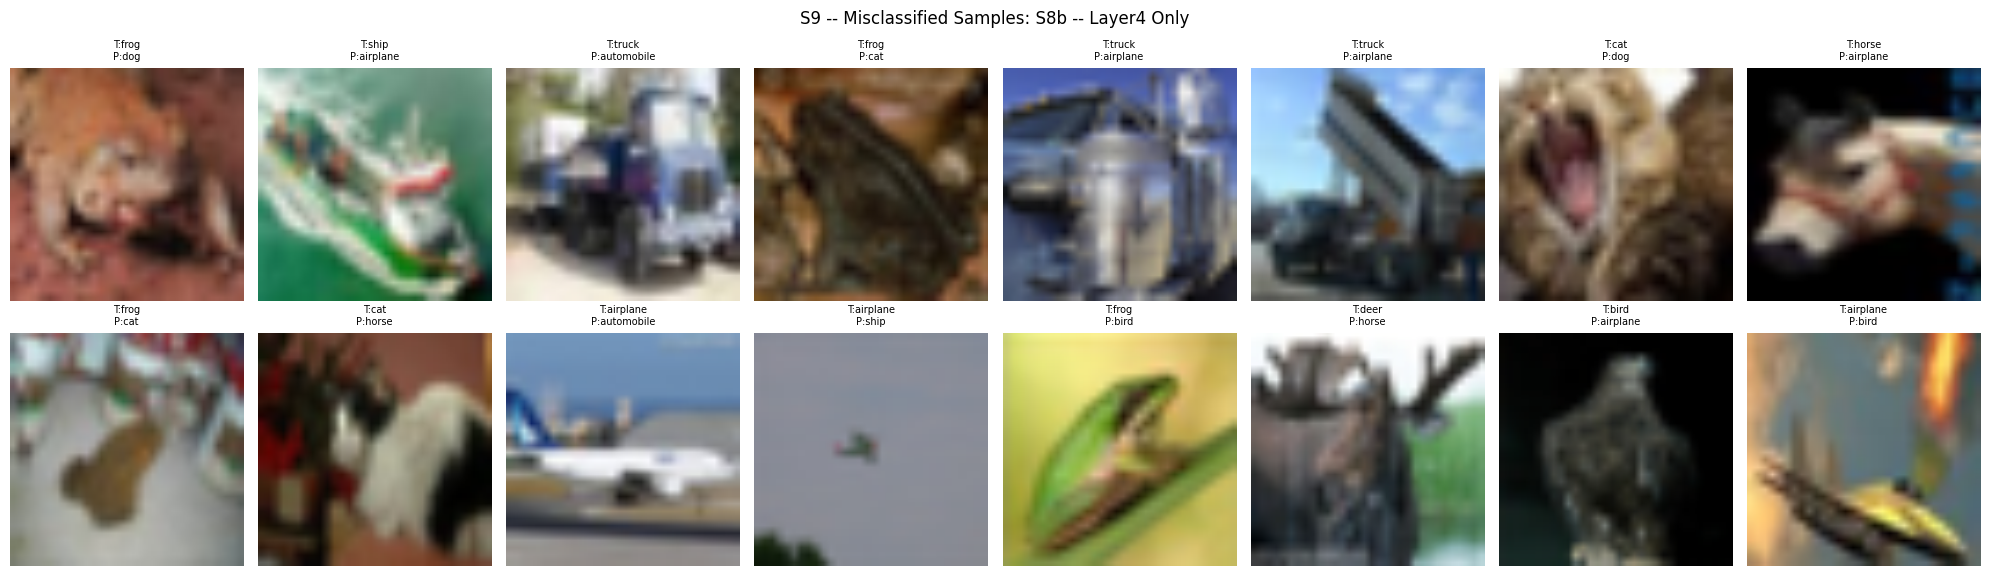

Saved: s9_misclass_s8b.png


In [21]:
# S9 Cell 2 -- Revised: Individual misclassification plots per model

checkpoints = [
    ('S7 -- Head Only',      S7_CHECKPOINT,  's9_misclass_s7.png'),
    ('S8a -- Full Unfreeze', S8A_CHECKPOINT, 's9_misclass_s8a.png'),
    ('S8b -- Layer4 Only',   S8B_CHECKPOINT, 's9_misclass_s8b.png'),
]

for label, checkpoint, filename in checkpoints:
    resnet50.load_state_dict(torch.load(checkpoint, weights_only=True))
    imgs, preds, trues = get_misclassified(resnet50, test_loader, device, n=16)

    fig, axes = plt.subplots(2, 8, figsize=(20, 6))
    axes = axes.flatten()

    for col in range(16):
        img = denormalize(imgs[col]).permute(1, 2, 0).numpy()
        axes[col].imshow(img)
        axes[col].set_title(
            f"T:{CLASS_NAMES[trues[col]]}\nP:{CLASS_NAMES[preds[col]]}",
            fontsize=7
        )
        axes[col].axis('off')

    plt.suptitle(f'S9 -- Misclassified Samples: {label}', fontsize=12)
    plt.tight_layout()
    plt.savefig(filename, dpi=150)
    plt.show()
    print(f"Saved: {filename}")

#### S9: Misclassification Observations
- All models correctly separate animal vs vehicle domains  
- Primary errors occur within categories sharing similar shapes:  
  - deer/horse, cat/dog, automobile/truck, airplane/ship  
- Background context and partial visibility identified as
  contributing error factors  
  - zoom in vs zoom out
- Error patterns consistent across S7, S8a, S8b  
    - indicates dataset-level constraints rather than model-specific failures  
- Root cause: 32x32 source resolution limits fine-grained feature preservation after upscaling to 224x224  

### Per-Class Accuracy Breakdown

S7 -- Head Only | Test Loss: 0.6376 | Test Acc: 0.7802 (78.02%)

S7 -- Head Only -- Per-Class Accuracy:
Class         Correct    Total      Acc
----------------------------------------
airplane          783     1000   78.30%
automobile        845     1000   84.50%
bird              780     1000   78.00%
cat               557     1000   55.70%
deer              669     1000   66.90%
dog               823     1000   82.30%
frog              897     1000   89.70%
horse             865     1000   86.50%
ship              690     1000   69.00%
truck             893     1000   89.30%
S8a -- Full Unfreeze | Test Loss: 0.3918 | Test Acc: 0.8949 (89.49%)

S8a -- Full Unfreeze -- Per-Class Accuracy:
Class         Correct    Total      Acc
----------------------------------------
airplane          883     1000   88.30%
automobile        945     1000   94.50%
bird              918     1000   91.80%
cat               869     1000   86.90%
deer              883     1000   88.30%
dog               82

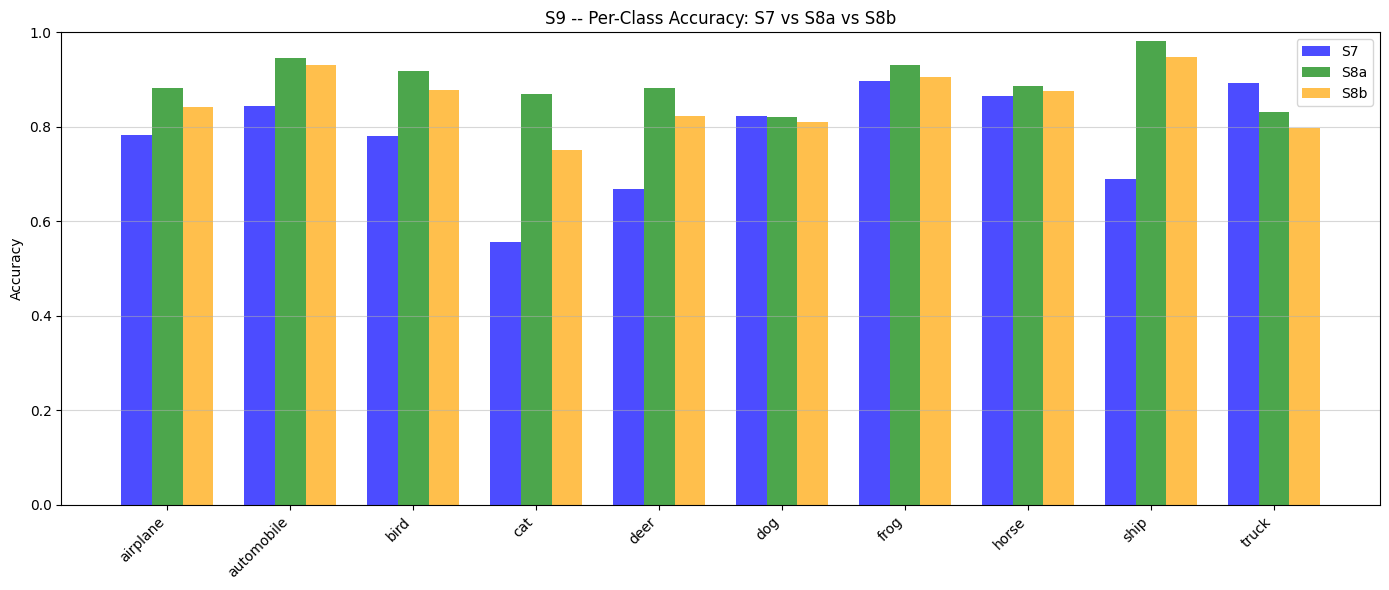

Plot saved: s9_per_class_accuracy.png


In [22]:
# S9 Cell 3: Per-Class Accuracy Breakdown -- All Three Models

from sklearn.metrics import classification_report
import numpy as np

checkpoints = [
    ('S7 -- Head Only',      S7_CHECKPOINT,  'S7'),
    ('S8a -- Full Unfreeze', S8A_CHECKPOINT, 'S8a'),
    ('S8b -- Layer4 Only',   S8B_CHECKPOINT, 'S8b'),
]

# Store per-class accuracy for comparison table
per_class_accs = {}

for label, checkpoint, short in checkpoints:
    resnet50.load_state_dict(torch.load(checkpoint, weights_only=True))
    _, _, preds, labels_true = evaluate_model(
        resnet50, test_loader, criterion, device, label
    )

    # Per-class accuracy
    preds_np = np.array(preds)
    labels_np = np.array(labels_true)
    class_accs = []

    print(f"\n{label} -- Per-Class Accuracy:")
    print(f"{'Class':<12} {'Correct':>8} {'Total':>8} {'Acc':>8}")
    print("-" * 40)

    for i, cls in enumerate(CLASS_NAMES):
        mask = labels_np == i
        correct = (preds_np[mask] == i).sum()
        total = mask.sum()
        acc = correct / total
        class_accs.append(acc)
        print(f"{cls:<12} {correct:>8} {total:>8} {acc:>8.2%}")

    per_class_accs[short] = class_accs

# Comparison table
print("\n\nPer-Class Accuracy Comparison:")
print(f"{'Class':<12} {'S7':>8} {'S8a':>8} {'S8b':>8}")
print("-" * 40)
for i, cls in enumerate(CLASS_NAMES):
    print(f"{cls:<12} {per_class_accs['S7'][i]:>8.2%} "
          f"{per_class_accs['S8a'][i]:>8.2%} "
          f"{per_class_accs['S8b'][i]:>8.2%}")

# Bar chart comparison
fig, ax = plt.subplots(figsize=(14, 6))
x = np.arange(len(CLASS_NAMES))
width = 0.25

ax.bar(x - width, per_class_accs['S7'],  width, label='S7',  color='blue',   alpha=0.7)
ax.bar(x,         per_class_accs['S8a'], width, label='S8a', color='green',  alpha=0.7)
ax.bar(x + width, per_class_accs['S8b'], width, label='S8b', color='orange', alpha=0.7)

ax.set_xticks(x)
ax.set_xticklabels(CLASS_NAMES, rotation=45, ha='right')
ax.set_ylabel('Accuracy')
ax.set_title('S9 -- Per-Class Accuracy: S7 vs S8a vs S8b')
ax.legend()
ax.grid(axis='y', alpha=0.5)
ax.set_ylim(0, 1.0)

plt.tight_layout()
plt.savefig('s9_per_class_accuracy.png', dpi=150)
plt.show()
print("Plot saved: s9_per_class_accuracy.png")

#### S9: Per-Class Accuracy Observations  
- Cat and deer: consistently weakest across all models  
  - shared morphology with dog/horse + upscaling artifact impact  
- Ship: largest improvement S7->S8a (69% -> 98.2%)  
  - distinctive features well-captured by full unfreeze and layer 4  
- Dog and truck: marginal regression after fine-tuning  
  - suggests feature boundary interference between similar classes  
- Fine-tuning improves overall accuracy but not uniformly  
  - class-level analysis reveals tradeoffs nont visible in aggregate metrics  

In [25]:
# S9: Final Results Summary

print("=" * 55)
print("CIFAR-10 Transfer Learning -- Final Results Summary")
print("=" * 55)

print(f"\n{'Model':<25} {'Test Acc':>10} {'Test Loss':>10}")
print("-" * 55)
for label, checkpoint, short in [
    ('S7  -- Head Only',     S7_CHECKPOINT,  'S7'),
    ('S8a -- Full Unfreeze', S8A_CHECKPOINT, 'S8a'),
    ('S8b -- Layer4 Only',   S8B_CHECKPOINT, 'S8b'),
]:
    acc  = per_class_accs[short]
    mean = sum(acc) / len(acc)
    print(f"{label:<25} {mean:>10.2%} "
          f"{results[label.strip()]['loss']:>10.4f}")

print("\nStrongest Class  (S8a): Ship      98.20%")
print("Weakest Class    (S7):  Cat       55.70%")
print("Most Consistent:        Frog/Horse -- stable across all models")
print("Largest Regression:     Truck     S7=89.3% -> S8b=79.8%")

print("\nFuture Experiments:")
print("  S8c -- layer3+4 unfreeze, lr=1e-4 # Testing Fine-tuning layers")
print("  S8d -- layer4 only, lr=1e-5 # Fine-tuning layer with slower learning")
print("  S8d -- layer3 only, lr=1e-4 # Lower-layer isolated to compare vs layer 4")
print("  Phase 4 -- full 50k dataset, 80/20 split # larger dataset")
print("=" * 55)

CIFAR-10 Transfer Learning -- Final Results Summary

Model                       Test Acc  Test Loss
-------------------------------------------------------
S7  -- Head Only              78.02%     0.6376
S8a -- Full Unfreeze          89.49%     0.3918
S8b -- Layer4 Only            85.62%     0.5771

Strongest Class  (S8a): Ship      98.20%
Weakest Class    (S7):  Cat       55.70%
Most Consistent:        Frog/Horse -- stable across all models
Largest Regression:     Truck     S7=89.3% -> S8b=79.8%

Future Experiments:
  S8c -- layer3+4 unfreeze, lr=1e-4 # Testing Fine-tuning layers
  S8d -- layer4 only, lr=1e-5 # Fine-tuning layer with slower learning
  S8d -- layer3 only, lr=1e-4 # Lower-layer isolated to compare vs layer 4
  Phase 4 -- full 50k dataset, 80/20 split # larger dataset
